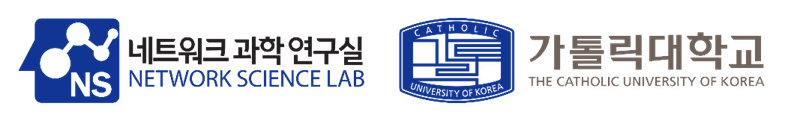

# Week 5: Deeper GNNs

# 0. Dataset

In [1]:
import math, time, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_dense_adj

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

/home/linux/miniconda3/envs/GNN/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/linux/miniconda3/envs/GNN/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Device: cuda


In [2]:
dataset = Planetoid(root=".", name="Cora")

data = dataset[0]

Processing...
Done!


### Data Analysis

In [3]:
print(f'Dataset: {dataset}')
print('-------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of edges: {data.edge_index.shape[1]} (directed) = {data.edge_index.shape[1] // 2} undirected')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')
print(f'Train / Val / Test nodes: {int(data.train_mask.sum())} / {int(data.val_mask.sum())} / {int(data.test_mask.sum())}')

# Information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Dataset: Cora()
-------------------
Number of graphs: 1
Number of nodes: 2708
Number of edges: 10556 (directed) = 5278 undirected
Number of features: 1433
Number of classes: 7
Train / Val / Test nodes: 140 / 500 / 1000

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


# Plot node degrees

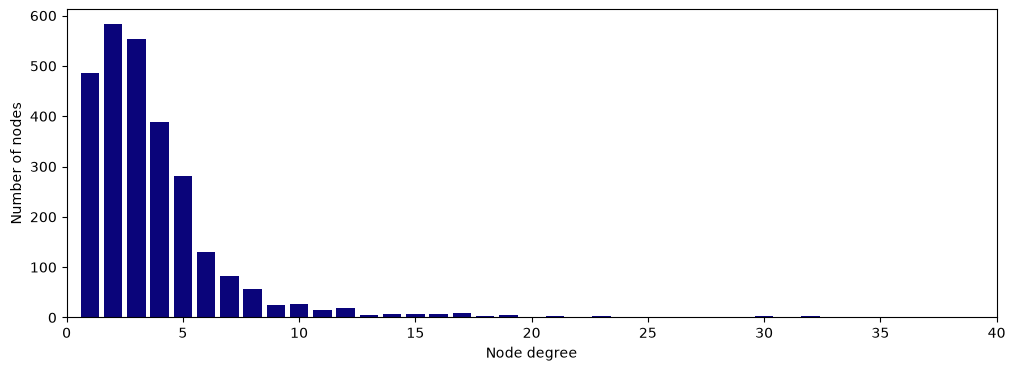

Max degree: 168 | Mean degree: 3.90
Connected components: 78 | Largest component: 2485 nodes


In [4]:
from torch_geometric.utils import degree
from collections import Counter

# Get list of degrees for each node
degrees = degree(data.edge_index[0], num_nodes=data.num_nodes).numpy()

# Count the number of nodes for each degree
numbers = Counter(degrees)

# Bar plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
ax.set_xlim(0, 40)
plt.bar(numbers.keys(), numbers.values(), color='#0A047A')
plt.show()

G_nx = nx.Graph()
G_nx.add_nodes_from(range(data.num_nodes))
G_nx.add_edges_from(data.edge_index.t().tolist())
components = list(nx.connected_components(G_nx))
print(f'Max degree: {int(degrees.max())} | Mean degree: {degrees.mean():.2f}')
print(f'Connected components: {len(components)} | Largest component: {max(len(c) for c in components)} nodes')

## 0.1. Dense adjacency and the GCN propagation matrix

In [5]:
N = data.num_nodes
num_features, num_classes = dataset.num_features, dataset.num_classes

X = data.x.to(device)
X = X / X.sum(dim=1, keepdim=True).clamp(min=1)          # row-normalise the bag-of-words features
y = data.y.to(device)
train_mask = data.train_mask.to(device)
val_mask = data.val_mask.to(device)
test_mask = data.test_mask.to(device)

# Binary, symmetric adjacency matrix without self-loops
A = to_dense_adj(data.edge_index, max_num_nodes=N)[0].to(device)
A = ((A + A.t()) > 0).float()
A.fill_diagonal_(0)

def normalize_adj(A, self_loops=True):
    """GCN propagation matrix  Â = D̃^{-1/2} (A + I) D̃^{-1/2}  (dense)."""
    if self_loops:
        A = A + torch.eye(A.size(0), device=A.device)
    deg = A.sum(dim=1)
    d_inv_sqrt = deg.pow(-0.5)
    d_inv_sqrt[torch.isinf(d_inv_sqrt)] = 0.
    return d_inv_sqrt[:, None] * A * d_inv_sqrt[None, :]

A_hat = normalize_adj(A)
print('A:', tuple(A.shape), '| undirected edges:', int(A.sum().item() // 2))

A: (2708, 2708) | undirected edges: 5278


## 0.2. Over-smoothing metrics
- **Dirichlet energy** $E(H)=\operatorname{tr}(H^\top \tilde L H)$ — total variation of the embeddings across edges.
- **MAD** — mean cosine distance $1-\frac{h_i\cdot h_j}{\|h_i\|\|h_j\|}$ between node pairs.

In deep networks the feature norm can also vanish or explode, so we additionally use the scale-free normalised energy $E(H)/\|H\|_F^2$ (a Rayleigh quotient in $[0,2]$) when comparing layers.

In [ ]:
def dirichlet_energy(H, A_hat, normalized=False):
    """Dirichlet energy  E(H) = tr(Hᵀ L̃ H) / N  with  L̃ = I - Â .
    E -> 0 means the representations are constant over every edge (over-smoothing).
    normalized=True returns the scale-free version tr(Hᵀ L̃ H) / ‖H‖²_F (Rayleigh quotient, in [0, 2]),
    which separates 'smoothing' from 'the features just shrink'."""
    H = H.double()
    energy = (H * (H - A_hat.double() @ H)).sum().item()
    if normalized:
        norm2 = H.pow(2).sum().item()
        return energy / norm2 if norm2 > 0 else 0.0
    return energy / H.size(0)

def mad(H):
    """Mean Average Distance: mean cosine distance 1 - h_i·h_j / (‖h_i‖‖h_j‖) over all node pairs."""
    H = H.double()
    H = H[H.abs().sum(dim=1) > 0]                       # ignore all-zero rows
    if H.size(0) < 2:
        return 0.0
    H = H / H.abs().max(dim=1, keepdim=True)[0]         # rescale rows first to avoid underflow
    Hn = F.normalize(H, dim=1)
    n = H.size(0)
    return ((1 - Hn @ Hn.t()).clamp(min=0).sum() / (n * (n - 1))).item()

## 0.3. Train / test function

In [7]:
def accuracy(pred_y, y):
    """Calculate accuracy."""
    return (pred_y == y).float().mean().item()

def train_model(model, inputs, epochs=300, lr=0.01, weight_decay=5e-4, optimizer=None,
                train_inputs_fn=None, split=None, patience=100, log_every=50, verbose=True):
    """Full-batch training with early stopping on validation accuracy.

    inputs          : tuple, the model is called as model(*inputs) for evaluation
    train_inputs_fn : optional callable returning *training-time* inputs (e.g. a DropEdge graph)
    split           : optional (y, train_mask, val_mask, test_mask); defaults to the Cora split
    Returns (best validation accuracy, test accuracy at the best validation epoch)."""
    yy, tr_m, va_m, te_m = split if split is not None else (y, train_mask, val_mask, test_mask)
    model = model.to(device)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val, best_test, best_epoch, bad, best_state = 0., 0., 0, 0, None

    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        optimizer.zero_grad()
        out = model(*(train_inputs_fn() if train_inputs_fn is not None else inputs))
        loss = F.cross_entropy(out[tr_m], yy[tr_m])
        loss.backward()
        optimizer.step()

        # Validation / test
        model.eval()
        with torch.no_grad():
            out = model(*inputs)
            val_loss = F.cross_entropy(out[va_m], yy[va_m]).item()
            pred = out.argmax(dim=1)
            train_acc, val_acc, test_acc = (accuracy(pred[m], yy[m]) for m in (tr_m, va_m, te_m))

        if val_acc > best_val:
            best_val, best_test, best_epoch, bad = val_acc, test_acc, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad += 1

        if verbose and (epoch == 1 or epoch % log_every == 0):
            print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {train_acc*100:>6.2f}% | '
                  f'Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')
        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)         
    if verbose:
        print(f'>> Best epoch {best_epoch} | Val Acc: {best_val*100:.2f}% | Test Acc: {best_test*100:.2f}%')
    return best_val, best_test

def repeat(make_model, inputs, seeds=(0, 1, 2), make_optimizer=None, **kwargs):
    """Train a fresh model for every seed; returns mean and std of the test accuracy."""
    accs = []
    for seed in seeds:
        set_seed(seed)
        model = make_model()
        optimizer = make_optimizer(model) if make_optimizer is not None else None
        accs.append(train_model(model, inputs, optimizer=optimizer, verbose=False, **kwargs)[1])
    return float(np.mean(accs)), float(np.std(accs))

results = {}

## 0.4. GCN layer

In [8]:
class GCNLayer(nn.Module):
    """Dense Kipf & Welling layer:  H' = Â H W + b."""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x, adj):
        return adj @ self.linear(x) + self.bias

class GCN(nn.Module):
    """Plain L-layer GCN. `norm` (e.g. PairNorm) and `residual` are optional."""
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers=2, dropout=0.5, norm=None, residual=False):
        super().__init__()
        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]
        self.layers = nn.ModuleList([GCNLayer(dims[i], dims[i + 1]) for i in range(num_layers)])
        self.norm = norm
        self.residual = residual
        self.dropout = dropout

    def forward(self, x, adj):
        self.hidden = []                          # hidden representations, used for layer-wise metrics
        for i, layer in enumerate(self.layers):
            x_in = x
            x = F.dropout(x, self.dropout, self.training)
            x = layer(x, adj)
            if i < len(self.layers) - 1:          # hidden layers
                if self.norm is not None:
                    x = self.norm(x)
                x = F.relu(x)
                if self.residual and x.shape == x_in.shape:
                    x = x + x_in
                self.hidden.append(x)
        return x

In [ ]:
set_seed(0)
gcn = GCN(num_features, 64, num_classes, num_layers=2)
print(gcn)
_, results['GCN (2 layers)'] = train_model(gcn, (X, A_hat))

GCN(
  (layers): ModuleList(
    (0): GCNLayer(
      (linear): Linear(in_features=1433, out_features=64, bias=False)
    )
    (1): GCNLayer(
      (linear): Linear(in_features=64, out_features=7, bias=False)
    )
  )
)
Epoch   1 | Train Loss: 1.946 | Train Acc:  37.86% | Val Loss: 1.95 | Val Acc: 18.40%
Epoch  50 | Train Loss: 0.713 | Train Acc:  97.86% | Val Loss: 1.08 | Val Acc: 80.80%
Epoch 100 | Train Loss: 0.335 | Train Acc:  99.29% | Val Loss: 0.83 | Val Acc: 78.60%
>> Best epoch 49 | Val Acc: 80.80% | Test Acc: 82.60%
CPU times: user 2.52 s, sys: 1.17 s, total: 3.68 s
Wall time: 3.58 s


# 1. What impedes deep GNNs?
## 1.1. Over-smoothing as repeated low-pass filtering
Without weights and non-linearities, an $l$-layer GCN computes $\hat A^l X$. The high-frequency components are multiplied by $(1-\lambda_i)^l \to 0$, so the Dirichlet energy and MAD collapse.

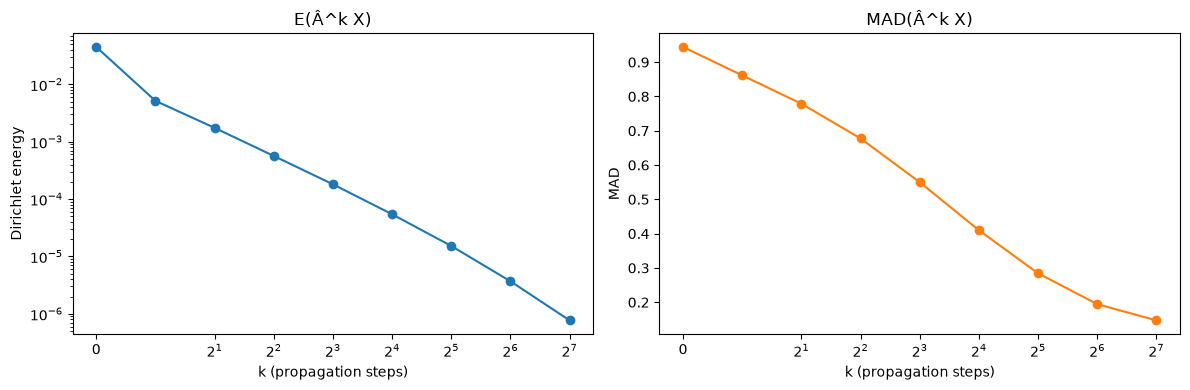

k =   0 | Dirichlet energy = 4.48e-02 | MAD = 0.9442
k =   1 | Dirichlet energy = 5.16e-03 | MAD = 0.8615
k =   2 | Dirichlet energy = 1.75e-03 | MAD = 0.7789
k =   4 | Dirichlet energy = 5.65e-04 | MAD = 0.6776
k =   8 | Dirichlet energy = 1.81e-04 | MAD = 0.5501
k =  16 | Dirichlet energy = 5.45e-05 | MAD = 0.4101
k =  32 | Dirichlet energy = 1.52e-05 | MAD = 0.2845
k =  64 | Dirichlet energy = 3.70e-06 | MAD = 0.1946
k = 128 | Dirichlet energy = 7.68e-07 | MAD = 0.1472


In [10]:
# Pure propagation  H^(k) = Â^k X  (no weights, no non-linearity)
ks = [0, 1, 2, 4, 8, 16, 32, 64, 128]
energies, mads = [], []
H = X.clone()
for k in range(max(ks) + 1):
    if k in ks:
        energies.append(dirichlet_energy(H, A_hat))
        mads.append(mad(H))
    H = A_hat @ H

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(ks, energies, 'o-'); ax[0].set_xscale('symlog', base=2)
ax[0].set_xlabel('k (propagation steps)'); ax[0].set_ylabel('Dirichlet energy'); ax[0].set_title('E(Â^k X)')
ax[1].plot(ks, mads, 'o-', color='C1'); ax[1].set_xscale('symlog', base=2)
ax[1].set_xlabel('k (propagation steps)'); ax[1].set_ylabel('MAD'); ax[1].set_title('MAD(Â^k X)')
plt.tight_layout(); plt.show()
for k, e, m in zip(ks, energies, mads):
    print(f'k = {k:>3} | Dirichlet energy = {e:.2e} | MAD = {m:.4f}')

Number of (numerically) zero eigenvalues = number of connected components: 78


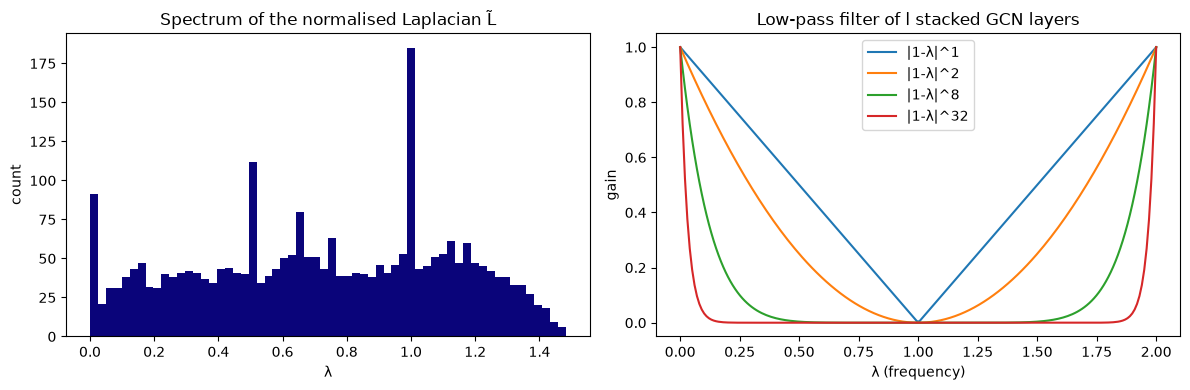

In [11]:
# Spectral view: Â = I - L̃ multiplies the i-th eigen-component by (1 - λ_i) at every layer
L_tilde = torch.eye(N, device=device) - A_hat
evals = torch.linalg.eigvalsh(L_tilde.double()).float().cpu()
print(f'Number of (numerically) zero eigenvalues = number of connected components: {(evals < 1e-6).sum().item()}')

lam = torch.linspace(0, 2, 200)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(evals.numpy(), bins=60, color='#0A047A'); ax[0].set_title('Spectrum of the normalised Laplacian L̃')
ax[0].set_xlabel('λ'); ax[0].set_ylabel('count')
for l in [1, 2, 8, 32]:
    ax[1].plot(lam, (1 - lam).abs() ** l, label=f'|1-λ|^{l}')
ax[1].set_xlabel('λ (frequency)'); ax[1].set_ylabel('gain'); ax[1].set_title('Low-pass filter of l stacked GCN layers')
ax[1].legend(); plt.tight_layout(); plt.show()

## 1.2. Stacking trained GCN layers
Deep plain GCNs suffer from over-smoothing **and** from optimisation problems (vanishing gradients). We first look at test accuracy vs. depth, then at the Dirichlet energy / MAD of every hidden layer of a 64-layer GCN.

GCN  2 layers | Test Acc: 82.53% ± 0.25
GCN  4 layers | Test Acc: 74.27% ± 2.25
GCN  8 layers | Test Acc: 16.87% ± 2.57
GCN 16 layers | Test Acc: 22.60% ± 6.55
GCN 32 layers | Test Acc: 20.03% ± 3.20


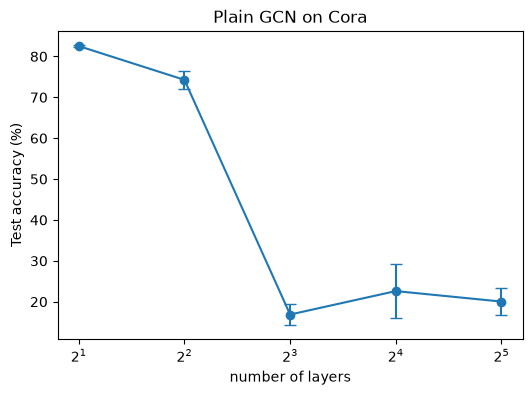

CPU times: user 57.4 s, sys: 6.41 s, total: 1min 3s
Wall time: 1min 4s


In [ ]:
# Test accuracy vs. depth (mean ± std over 3 seeds)
depths = [2, 4, 8, 16, 32]
depth_acc = {}
for L in depths:
    depth_acc[L] = repeat(lambda: GCN(num_features, 64, num_classes, num_layers=L), (X, A_hat), epochs=200)
    print(f'GCN {L:>2} layers | Test Acc: {depth_acc[L][0]*100:.2f}% ± {depth_acc[L][1]*100:.2f}')

plt.figure(figsize=(6, 4))
plt.errorbar(depths, [depth_acc[L][0] * 100 for L in depths], yerr=[depth_acc[L][1] * 100 for L in depths],
             fmt='o-', capsize=4)
plt.xscale('log', base=2); plt.xlabel('number of layers'); plt.ylabel('Test accuracy (%)')
plt.title('Plain GCN on Cora'); plt.show()

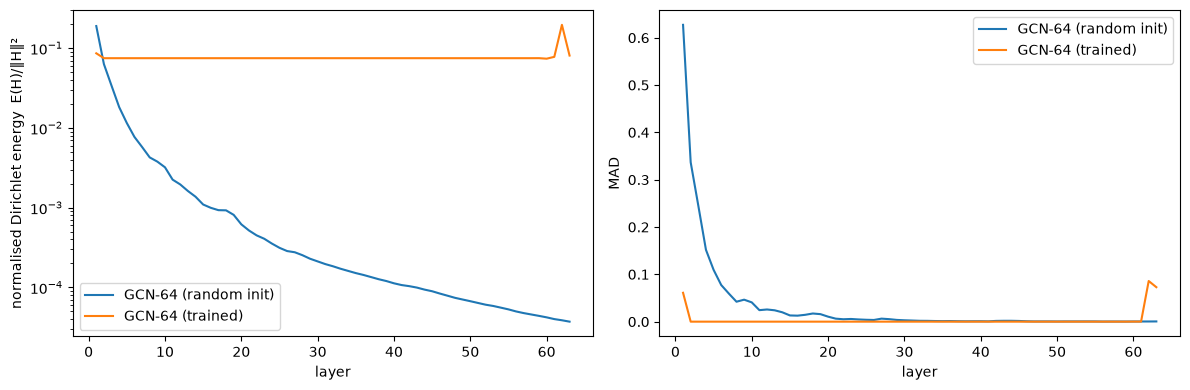

In [13]:
def layerwise_metrics(model):
    """Normalised Dirichlet energy and MAD of every hidden layer of a GCN (eval mode, no dropout)."""
    model = model.to(device).eval()
    with torch.no_grad():
        model(X, A_hat)
    return [dirichlet_energy(h, A_hat, normalized=True) for h in model.hidden], [mad(h) for h in model.hidden]

def plot_layerwise(models):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for name, model in models.items():
        E, M = layerwise_metrics(model)
        layers = range(1, len(E) + 1)
        ax[0].semilogy(layers, E, label=name)
        ax[1].plot(layers, M, label=name)
    ax[0].set_ylabel('normalised Dirichlet energy  E(H)/‖H‖²'); ax[1].set_ylabel('MAD')
    for a in ax:
        a.set_xlabel('layer'); a.legend()
    plt.tight_layout(); plt.show()

# Hidden representations of a 64-layer GCN, (a) at random initialisation and (b) after training
set_seed(0)
gcn64_init = GCN(num_features, 64, num_classes, num_layers=64)
set_seed(0)
gcn64_trained = GCN(num_features, 64, num_classes, num_layers=64)
train_model(gcn64_trained, (X, A_hat), epochs=200, verbose=False)
plot_layerwise({'GCN-64 (random init)': gcn64_init, 'GCN-64 (trained)': gcn64_trained})

# 2. Skip connections
## 2.1. DeepGCNs
Residual learning for GCNs: $\mathcal G_{l+1} = \mathcal F(\mathcal G_l, \mathcal W_l) + \mathcal G_l$.
DeepGCNs build PlainGCN / ResGCN / DenseGCN backbones with dilated k-NN graphs for point clouds. On a citation graph the graph is fixed, so we keep the three backbone blocks and use DeeperGCN's `GENConv` (softmax aggregation) and the pre-activation **res+** block.

In [14]:
class GENConv(nn.Module):
    """Generalised aggregation layer of DeeperGCN (SoftMax_Agg):
         m_j  = ReLU(h_j) + ε
         a_i  = Σ_{j∈N(i)} softmax_j(t · m_j) · m_j        (per channel, t learnable)
         h_i' = MLP(h_i + a_i)
    t -> 0 gives mean aggregation, t -> ∞ gives max aggregation."""
    def __init__(self, in_dim, out_dim, t=1.0, learn_t=True, eps=1e-7):
        super().__init__()
        self.t = nn.Parameter(torch.tensor([t])) if learn_t else t
        self.eps = eps
        self.mlp = nn.Sequential(nn.Linear(in_dim, 2 * in_dim), nn.LayerNorm(2 * in_dim),
                                 nn.ReLU(), nn.Linear(2 * in_dim, out_dim))

    def forward(self, x, adj):
        # adj is the binary adjacency. The softmax weight of a message only depends on the source
        # node j and the channel, so the per-node softmax is two dense mat-muls (numerator / denominator).
        m = F.relu(x) + self.eps
        logits = self.t * m
        w = torch.exp(logits - logits.max(dim=0, keepdim=True)[0])   # numerically stable
        agg = (adj @ (w * m)) / (adj @ w).clamp(min=1e-16)
        return self.mlp(x + agg)

class DeepGCNLayer(nn.Module):
    """Backbone blocks of DeepGCNs:
       'plain' : x' = act(norm(conv(x)))
       'res'   : x' = x + act(norm(conv(x)))                  (ResGCN)
       'res+'  : x' = x + conv(dropout(act(norm(x))))         (pre-activation residual, DeeperGCN)
       'dense' : x' = [x || act(norm(conv(x)))]               (DenseGCN)"""
    def __init__(self, conv, norm, block='res+', dropout=0.1):
        super().__init__()
        self.conv, self.norm, self.block, self.dropout = conv, norm, block, dropout

    def forward(self, x, adj):
        if self.block == 'res+':
            h = F.dropout(F.relu(self.norm(x)), self.dropout, self.training)
            return x + self.conv(h, adj)
        h = F.dropout(F.relu(self.norm(self.conv(x, adj))), self.dropout, self.training)
        if self.block == 'res':
            return x + h
        if self.block == 'dense':
            return torch.cat([x, h], dim=1)
        return h                  

class DeepGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers=16, block='res+', dropout=0.1, growth=16):
        super().__init__()
        self.encoder = nn.Linear(in_dim, hidden_dim)
        self.layers = nn.ModuleList()
        dim = hidden_dim
        for _ in range(num_layers):
            out = growth if block == 'dense' else hidden_dim
            conv = GENConv(dim, out)
            norm = nn.LayerNorm(dim if block == 'res+' else out)
            self.layers.append(DeepGCNLayer(conv, norm, block, dropout))
            dim = dim + growth if block == 'dense' else dim
        self.final_norm = nn.LayerNorm(dim)
        self.classifier = nn.Linear(dim, out_dim)
        self.dropout = dropout

    def forward(self, x, adj):
        x = F.dropout(x, 0.5, self.training)
        x = self.encoder(x)
        for layer in self.layers:
            x = layer(x, adj)
        x = F.dropout(F.relu(self.final_norm(x)), 0.5, self.training)
        return self.classifier(x)

In [ ]:
for block in ['plain', 'res', 'res+', 'dense']:
    set_seed(0)
    model = DeepGCN(num_features, 64, num_classes, num_layers=16, block=block)
    _, acc = train_model(model, (X, A), epochs=300, verbose=False)
    print(f'DeepGCN 16 layers | block = {block:<5} | Test Acc: {acc*100:.2f}%')
    if block == 'res+':
        results['DeepGCN (ResGCN+)'] = acc

DeepGCN 16 layers | block = plain | Test Acc: 31.90%
DeepGCN 16 layers | block = res   | Test Acc: 77.30%
DeepGCN 16 layers | block = res+  | Test Acc: 74.50%
DeepGCN 16 layers | block = dense | Test Acc: 77.70%
CPU times: user 1min 17s, sys: 11.8 s, total: 1min 29s
Wall time: 1min 27s


## 2.2. GCNII: initial residual + identity mapping
$$H^{(\ell+1)} = \sigma\Big(\big((1-\alpha)\hat A H^{(\ell)} + \alpha H^{(0)}\big)\big((1-\beta_\ell) I_n + \beta_\ell W^{(\ell)}\big)\Big),\qquad \beta_\ell = \log(\lambda/\ell + 1)$$

In [16]:
class GCNIILayer(nn.Module):
    """H' = σ( ((1-α) Â H + α H⁰) ((1-β) I + β W) )
       initial residual : α H⁰ keeps a fraction of the input representation in every layer
       identity mapping : (1-β) I + β W keeps the layer close to the identity when β is small"""
    def __init__(self, channels):
        super().__init__()
        self.weight = nn.Linear(channels, channels, bias=False)

    def forward(self, h, h0, adj, alpha, beta):
        support = (1 - alpha) * (adj @ h) + alpha * h0           # initial residual
        return (1 - beta) * support + beta * self.weight(support) # identity mapping

class GCNII(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers=64, alpha=0.1, lamda=0.5, dropout=0.6):
        super().__init__()
        self.fc_in = nn.Linear(in_dim, hidden_dim)
        self.convs = nn.ModuleList([GCNIILayer(hidden_dim) for _ in range(num_layers)])
        self.fc_out = nn.Linear(hidden_dim, out_dim)
        self.alpha, self.lamda, self.dropout = alpha, lamda, dropout

    def forward(self, x, adj):
        x = F.dropout(x, self.dropout, self.training)
        h0 = F.relu(self.fc_in(x))
        h = h0
        for l, conv in enumerate(self.convs, start=1):
            beta = math.log(self.lamda / l + 1)                 # β_l = log(λ/l + 1) decays with depth
            h = F.dropout(h, self.dropout, self.training)
            h = F.relu(conv(h, h0, adj, self.alpha, beta))
        h = F.dropout(h, self.dropout, self.training)
        return self.fc_out(h)

def gcnii_optimizer(model, lr=0.01):
    # As in the paper: strong L2 on the propagation weights, weak L2 on the dense input/output layers
    return torch.optim.Adam([
        dict(params=model.convs.parameters(), weight_decay=0.01),
        dict(params=list(model.fc_in.parameters()) + list(model.fc_out.parameters()), weight_decay=5e-4),
    ], lr=lr)

In [17]:
set_seed(0)
gcnii = GCNII(num_features, 64, num_classes, num_layers=64, alpha=0.1, lamda=0.5, dropout=0.6)
_, results['GCNII'] = train_model(gcnii, (X, A_hat), epochs=500, optimizer=gcnii_optimizer(gcnii), log_every=100)
gcnii.eval()
with torch.no_grad():
    out = gcnii(X, A_hat)
print(f'64-layer GCNII output: Dirichlet energy = {dirichlet_energy(out, A_hat):.2e} | MAD = {mad(out):.4f}')

Epoch   1 | Train Loss: 1.950 | Train Acc:  14.29% | Val Loss: 1.94 | Val Acc: 7.20%
Epoch 100 | Train Loss: 1.242 | Train Acc:  92.86% | Val Loss: 1.33 | Val Acc: 78.20%
Epoch 200 | Train Loss: 0.954 | Train Acc:  92.86% | Val Loss: 1.06 | Val Acc: 81.60%
Epoch 300 | Train Loss: 0.898 | Train Acc:  95.71% | Val Loss: 0.93 | Val Acc: 82.00%
Epoch 400 | Train Loss: 0.869 | Train Acc:  97.14% | Val Loss: 0.89 | Val Acc: 82.80%
>> Best epoch 360 | Val Acc: 83.80% | Test Acc: 84.00%
64-layer GCNII output: Dirichlet energy = 4.10e-01 | MAD = 0.5954


# 3. Normalisation / regularisation
## 3.1. PairNorm
Center then rescale so that the total pairwise distance $\sum_{i,j}\|\dot x_i-\dot x_j\|^2$ stays constant across layers.

In [ ]:
class PairNorm(nn.Module):
    """PairNorm (Zhao & Akoglu, ICLR 2020):
         center : x̃_i^c = x̃_i - (1/n) Σ_i x̃_i
         scale  : ẋ_i   = s · √n · x̃_i^c / ‖X̃^c‖_F = s · x̃_i^c / sqrt((1/n) Σ_i ‖x̃_i^c‖²)
       keeps the total pairwise squared distance constant from layer to layer.
       mode 'PN-SI'  : center, then scale every node individually   ẋ_i = s · x̃_i^c / ‖x̃_i^c‖
       mode 'PN-SCS' : scale individually and center *simultaneously* (code-only variant of the official repo):
                       ẋ_i = s · x̃_i / ‖x̃_i‖ − (1/n) Σ_j x̃_j   (the mean of the *un-scaled* input is subtracted)"""
    def __init__(self, mode='PN', scale=1.0, eps=1e-6):
        super().__init__()
        self.mode, self.scale, self.eps = mode, scale, eps

    def forward(self, x):
        col_mean = x.mean(dim=0, keepdim=True)
        if self.mode == 'PN-SCS':
            return self.scale * x / (self.eps + x.pow(2).sum(dim=1, keepdim=True)).sqrt() - col_mean
        x = x - col_mean                                                      # center
        if self.mode == 'PN':
            return self.scale * x / (self.eps + x.pow(2).sum(dim=1).mean()).sqrt()
        return self.scale * x / (self.eps + x.pow(2).sum(dim=1, keepdim=True)).sqrt()   # PN-SI

In [ ]:
# PairNorm is used together with the residual update:  h^{l+1} = σ(Σ_j Â_ij h_j W) + h^l
variants = {
    'plain':        dict(),
    'residual':     dict(residual=True),
    'PN':           dict(norm=PairNorm('PN')),
    'PN + res':     dict(norm=PairNorm('PN'), residual=True),
    'PN-SI + res':  dict(norm=PairNorm('PN-SI'), residual=True),
    'PN-SCS + res': dict(norm=PairNorm('PN-SCS'), residual=True),
}
for L in [16, 32]:
    line = []
    for name, kw in variants.items():
        mean, std = repeat(lambda: GCN(num_features, 64, num_classes, num_layers=L, **kw), (X, A_hat), epochs=200)
        line.append(f'{name} {mean*100:.1f}±{std*100:.1f}')
        if L == 32 and name == 'PN + res':
            results['GCN + PairNorm'] = mean
    print(f'{L} layers | ' + ' | '.join(line))

16 layers | plain 22.6±6.6 | residual 74.6±2.7 | PN 52.3±4.0 | PN + res 76.0±1.0 | PN-SI + res 76.3±0.6 | PN-SCS + res 77.3±0.4
32 layers | plain 20.0±3.2 | residual 29.4±16.8 | PN 32.4±1.3 | PN + res 74.9±1.2 | PN-SI + res 76.2±1.1 | PN-SCS + res 71.4±5.6


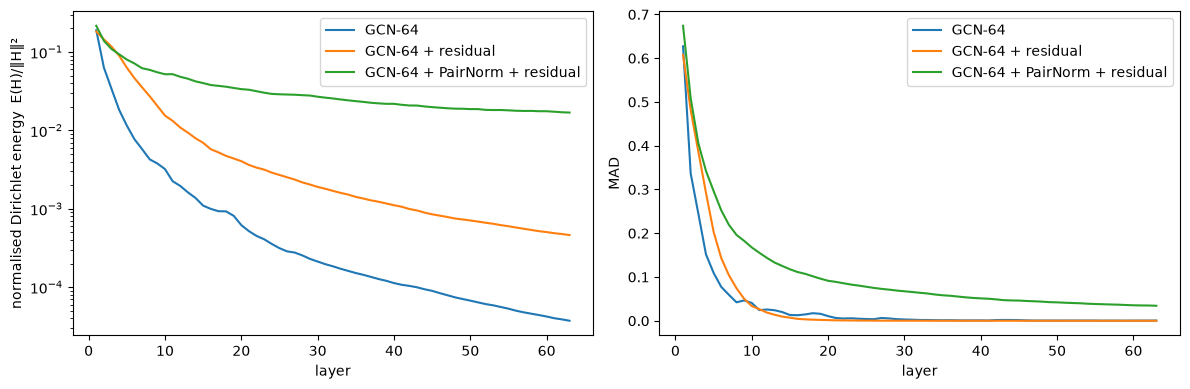

In [20]:
# Layer-wise Dirichlet energy / MAD at initialisation: PairNorm keeps the representations apart
set_seed(0)
plot_layerwise({'GCN-64': GCN(num_features, 64, num_classes, num_layers=64),
                'GCN-64 + residual': GCN(num_features, 64, num_classes, num_layers=64, residual=True),
                'GCN-64 + PairNorm + residual': GCN(num_features, 64, num_classes, num_layers=64,
                                                    norm=PairNorm('PN'), residual=True)})

## 3.2. DropEdge
Randomly remove edges at every epoch: a data augmentation that slows down convergence to the over-smoothed subspace and reduces overfitting.

In [21]:
def drop_edge(A, p=0.3):
    """DropEdge: remove every undirected edge independently with probability p (Bernoulli mask).
    Must be re-sampled at every training epoch; the full graph is used at test time."""
    keep = (torch.rand_like(A) > p).float().triu(diagonal=1)
    keep = keep + keep.t()                                  # keep the graph symmetric
    return A * keep

A_drop = drop_edge(A, p=0.3)
print(f'Edges before: {int(A.sum()) // 2} | after DropEdge(p=0.3): {int(A_drop.sum()) // 2}')

Edges before: 5278 | after DropEdge(p=0.3): 3698


In [22]:

for L in [2, 4, 8]:
    plain = repeat(lambda: GCN(num_features, 64, num_classes, num_layers=L), (X, A_hat), epochs=200)
    drop = repeat(lambda: GCN(num_features, 64, num_classes, num_layers=L), (X, A_hat), epochs=200,
                  train_inputs_fn=lambda: (X, normalize_adj(drop_edge(A, p=0.5))))   # new graph every epoch
    print(f'GCN {L} layers | without DropEdge: {plain[0]*100:.2f}% ± {plain[1]*100:.2f} | '
          f'with DropEdge (p=0.5): {drop[0]*100:.2f}% ± {drop[1]*100:.2f}')
    if L == 4:
        results['GCN + DropEdge'] = drop[0]

GCN 2 layers | without DropEdge: 82.53% ± 0.25 | with DropEdge (p=0.5): 82.50% ± 0.78
GCN 4 layers | without DropEdge: 74.27% ± 2.25 | with DropEdge (p=0.5): 77.43% ± 1.03
GCN 8 layers | without DropEdge: 16.87% ± 2.57 | with DropEdge (p=0.5): 26.37% ± 4.89


# 4. Graph rewiring (over-squashing)
Change the graph instead of the model: add edges across bottlenecks (negative curvature / small spectral gap).

In [ ]:
# Rewiring experiments are run on the largest connected component (LCC),
# so that the spectral gap λ₂ of the normalised Laplacian is well defined (Cheeger inequality).
lcc_nodes = sorted(max(nx.connected_components(G_nx), key=len))
idx = torch.tensor(lcc_nodes, device=device)
A_lcc = A[idx][:, idx]
X_lcc = X[idx]
split_lcc = (y[idx], train_mask[idx], val_mask[idx], test_mask[idx])
print(f'LCC: {len(lcc_nodes)} nodes, {int(A_lcc.sum()) // 2} edges, '
      f'{int(split_lcc[1].sum())}/{int(split_lcc[2].sum())}/{int(split_lcc[3].sum())} train/val/test nodes')

def spectral_gap(A):
    """λ₂ of L̃ = I - D̃^{-1/2}(A+I)D̃^{-1/2}: small gap = bottleneck (over-squashing)."""
    L = torch.eye(A.size(0), device=A.device, dtype=torch.float64) - normalize_adj(A.double())
    return torch.linalg.eigvalsh(L)[1].item()

def gcn_on_graph(A_graph, X_graph, split, name, normalize=True, seed=0):
    set_seed(seed)
    adj = normalize_adj(A_graph) if normalize else A_graph
    model = GCN(X_graph.size(1), 64, num_classes, num_layers=2)
    _, test_acc = train_model(model, (X_graph, adj), split=split, verbose=False)
    print(f'{name:<22} | Test Acc: {test_acc*100:.2f}%')
    return test_acc

rewire_stats = {'Original': dict(edges=int(A_lcc.sum()) // 2, gap=spectral_gap(A_lcc))}
rewire_stats['Original']['acc'] = gcn_on_graph(A_lcc, X_lcc, split_lcc, 'GCN on original LCC')
print(f"Spectral gap λ₂ of the LCC: {rewire_stats['Original']['gap']:.5f}")

LCC: 2485 nodes, 5069 edges, 122/459/915 train/val/test nodes
GCN on original LCC    | Test Acc: 81.31%
Spectral gap λ₂ of the LCC: 0.00362


## 4.1. Balanced Forman curvature
$$\mathrm{Ric}(i,j) = \frac{2}{d_i}+\frac{2}{d_j}-2+2\frac{|\sharp_\Delta|}{\max(d_i,d_j)}+\frac{|\sharp_\Delta|}{\min(d_i,d_j)}+\frac{\gamma_{\max}^{-1}}{\max(d_i,d_j)}\big(|\sharp^{\square}_i|+|\sharp^{\square}_j|\big)$$

In [ ]:
def to_neighbor_sets(A):
    A_cpu = A.cpu()
    return [set(torch.nonzero(A_cpu[i]).flatten().tolist()) for i in range(A.size(0))]

def bfc_edge(nbrs, i, j):
    """Balanced Forman curvature Ric(i, j) of an edge i~j."""
    Ni, Nj = nbrs[i], nbrs[j]
    di, dj = len(Ni), len(Nj)
    if min(di, dj) <= 1:                        # base case
        return 0.0
    d_max, d_min = max(di, dj), min(di, dj)
    tri = len(Ni & Nj)                          # ♯Δ(i, j)
    sq_i, sq_j, gamma_max = 0, 0, 0
    # ♯□_i: k ∈ S1(i) \ S1(j), k ≠ j, closing a 4-cycle i-k-w-j without diagonals
    for k in Ni - Nj - {j}:
        W = (nbrs[k] & Nj) - Ni - {i}
        if W:
            sq_i += 1
            gamma_max = max(gamma_max, len(W))  # 4-cycles through a common node
    # ♯□_j: symmetric
    for k in Nj - Ni - {i}:
        W = (nbrs[k] & Ni) - Nj - {j}
        if W:
            sq_j += 1
            gamma_max = max(gamma_max, len(W))
    ric = 2 / di + 2 / dj - 2 + 2 * tri / d_max + tri / d_min
    if gamma_max > 0:
        ric += (sq_i + sq_j) / (gamma_max * d_max)
    return ric

def bfc_all(nbrs):
    return {(i, j): bfc_edge(nbrs, i, j) for i in range(len(nbrs)) for j in nbrs[i] if i < j}

♯□_0(0,1) = {2, 3} | ♯□_1(0,1) = {5} | ♯Δ(0,1) = {6}
Ric(0,1) = 0.1000


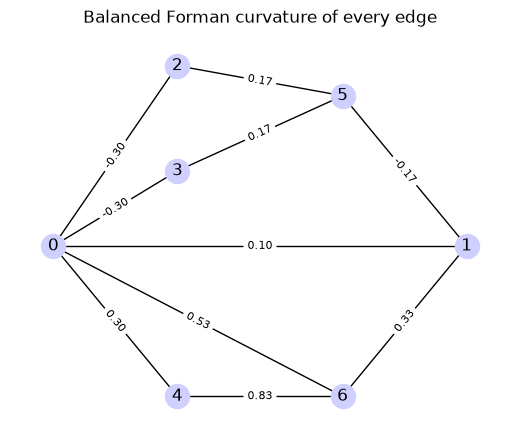

In [25]:
# Walkthrough example
toy_edges = [(0, 1), (0, 2), (0, 3), (0, 4), (0, 6), (2, 5), (3, 5), (5, 1), (1, 6), (4, 6)]
toy = [set() for _ in range(7)]
for u, v in toy_edges:
    toy[u].add(v); toy[v].add(u)

sq0 = {k for k in toy[0] - toy[1] - {1} if (toy[k] & toy[1]) - toy[0] - {0}}
sq1 = {k for k in toy[1] - toy[0] - {0} if (toy[k] & toy[0]) - toy[1] - {1}}
print('♯□_0(0,1) =', sq0, '| ♯□_1(0,1) =', sq1, '| ♯Δ(0,1) =', toy[0] & toy[1])
print(f'Ric(0,1) = {bfc_edge(toy, 0, 1):.4f}')

G_toy = nx.Graph(toy_edges)
pos = {0: (0, 0), 1: (2, 0), 2: (0.6, 1.2), 3: (0.6, 0.5), 4: (0.6, -1), 5: (1.4, 1), 6: (1.4, -1)}
labels = {e: f'{bfc_edge(toy, *e):.2f}' for e in G_toy.edges()}
plt.figure(figsize=(5, 4))
nx.draw(G_toy, pos, with_labels=True, node_color='#d0d0ff')
nx.draw_networkx_edge_labels(G_toy, pos, edge_labels=labels, font_size=8)
plt.title('Balanced Forman curvature of every edge'); plt.show()

5069 edges | min Ric = -1.812 | mean Ric = -0.550 | negatively curved edges: 77.8%


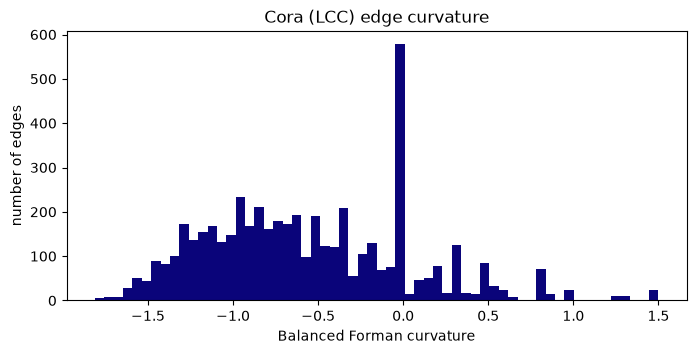

In [ ]:
nbrs_lcc = to_neighbor_sets(A_lcc)
curv_lcc = bfc_all(nbrs_lcc)
vals = np.array(list(curv_lcc.values()))
print(f'{len(vals)} edges | min Ric = {vals.min():.3f} | mean Ric = {vals.mean():.3f} | '
      f'negatively curved edges: {(vals < 0).mean()*100:.1f}%')
rewire_stats['Original']['min_ric'] = vals.min()

plt.figure(figsize=(8, 3.5))
plt.hist(vals, bins=60, color='#0A047A')
plt.xlabel('Balanced Forman curvature'); plt.ylabel('number of edges'); plt.title('Cora (LCC) edge curvature')
plt.show()

## 4.2. SDRF — Stochastic Discrete Ricci Flow
Repeatedly take the most negatively curved edge $i\sim j$, add the edge $k\sim l$ ($k\in B_1(i), l\in B_1(j)$) that improves $\mathrm{Ric}(i,j)$ the most (sampled with softmax$(\tau x)$), and optionally remove the most positively curved edge above $C^+$.

In [ ]:
def _refresh(curv, nbrs, nodes):
    """Recompute Ric for every edge touching `nodes` (the only edges whose curvature can change)."""
    for a in nodes:
        for b in nbrs[a]:
            e = (min(a, b), max(a, b))
            curv[e] = bfc_edge(nbrs, *e)

def sdrf(A, num_iterations=100, tau=100.0, C_plus=None, seed=0):
    """Stochastic Discrete Ricci Flow."""
    rng = np.random.default_rng(seed)
    nbrs = to_neighbor_sets(A)
    curv = bfc_all(nbrs)
    added, removed = [], []
    for _ in range(num_iterations):
        # 1) edge i~j with minimal curvature
        (i, j), c_ij = min(curv.items(), key=lambda kv: kv[1])
        # candidate edges k~l, k ∈ B1(i), l ∈ B1(j); x_kl = Ric_kl(i,j) - Ric(i,j)
        cand, gain = [], []
        for k in nbrs[i] | {i}:
            for l in nbrs[j] | {j}:
                if k == l or l in nbrs[k]:
                    continue
                nbrs[k].add(l); nbrs[l].add(k)
                gain.append(bfc_edge(nbrs, i, j) - c_ij)
                nbrs[k].remove(l); nbrs[l].remove(k)
                cand.append((k, l))
        if not cand:
            break
        g = np.array(gain)
        p = np.exp(tau * (g - g.max()))
        k, l = cand[rng.choice(len(cand), p=p / p.sum())]       # sample from softmax(τ x)
        nbrs[k].add(l); nbrs[l].add(k)
        added.append((k, l))
        _refresh(curv, nbrs, nbrs[k] | nbrs[l])
        # 2) remove the most positively curved edge if Ric > C+
        if C_plus is not None:
            (u, v), c_uv = max(curv.items(), key=lambda kv: kv[1])
            if c_uv > C_plus:
                nbrs[u].remove(v); nbrs[v].remove(u)
                del curv[(u, v)]
                removed.append((u, v))
                _refresh(curv, nbrs, nbrs[u] | nbrs[v] | {u, v})
    A_new = torch.zeros_like(A)
    for a in range(len(nbrs)):
        for b in nbrs[a]:
            A_new[a, b] = 1.
    return A_new, added, removed, curv

In [ ]:
A_sdrf, sdrf_added, sdrf_removed, curv_sdrf = sdrf(A_lcc, num_iterations=100, tau=100.0, C_plus=0.95)
v = np.array(list(curv_sdrf.values()))
rewire_stats['SDRF'] = dict(edges=int(A_sdrf.sum()) // 2, gap=spectral_gap(A_sdrf), min_ric=v.min())
print(f"SDRF: +{len(sdrf_added)} / -{len(sdrf_removed)} edges | min Ric {rewire_stats['Original']['min_ric']:.3f} -> {v.min():.3f} "
      f"| λ₂ {rewire_stats['Original']['gap']:.5f} -> {rewire_stats['SDRF']['gap']:.5f}")
rewire_stats['SDRF']['acc'] = gcn_on_graph(A_sdrf, X_lcc, split_lcc, 'GCN + SDRF')

SDRF: +100 / -60 edges | min Ric -1.812 -> -1.595 | λ₂ 0.00362 -> 0.00367
GCN + SDRF             | Test Acc: 82.30%


## 4.3. FoSR — First-order Spectral Rewiring
Increase the spectral gap $\lambda_2$ directly (Cheeger inequality): the first-order change of $\lambda_2$ when edge $(u,v)$ is added is proportional to $-x_u x_v/\sqrt{(1+d_u)(1+d_v)}$, where $x$ is the second eigenvector.

In [ ]:
def fosr(A, num_edges=100, power_iters=10, initial_power_iters=100, seed=0):
    """First-order Spectral Rewiring (FoSR, Karhadkar et al., ICLR 2023).
    Repeatedly adds the missing edge that increases the spectral gap the most to first order:
        (u, v) = argmin_{(u,v) ∉ E}  x_u x_v / sqrt((1 + d_u)(1 + d_v))
    where x ≈ second eigenvector of D^{-1/2} A D^{-1/2} (plain degrees, *no* self-loops;
    the 1 + d terms are the degrees after inserting (u, v), Proposition 5), tracked cheaply with a few
    power iterations per step."""
    A = A.clone()
    n = A.size(0)
    gen = torch.Generator().manual_seed(seed)
    x = (2 * torch.rand(n, generator=gen) - 1).to(A.device)
    eye = torch.eye(n, dtype=torch.bool, device=A.device)

    def power_iteration(x, A, iters):
        deg = A.sum(dim=1)
        d_inv_sqrt = deg.clamp(min=1).pow(-0.5)
        v1 = deg.sqrt()
        v1 = v1 / v1.norm()                   # top eigenvector of D^-1/2 A D^-1/2 (eigenvalue 1)
        for _ in range(iters):
            x = x - (x @ v1) * v1             # deflate the trivial eigenvector
            x = x + d_inv_sqrt * (A @ (d_inv_sqrt * x))   # power iteration on (I + D^-1/2 A D^-1/2) -> 2nd eigenvector
            x = x / x.norm()
        return x

    x = power_iteration(x, A, initial_power_iters)
    added = []
    for _ in range(num_edges):
        s = x / (A.sum(dim=1) + 1).sqrt()
        score = (s[:, None] * s[None, :]).masked_fill((A > 0) | eye, float('inf'))
        u, v = divmod(torch.argmin(score).item(), n)
        A[u, v] = A[v, u] = 1.
        added.append((u, v))
        x = power_iteration(x, A, power_iters)
    return A, added

In [ ]:
A_fosr, fosr_added = fosr(A_lcc, num_edges=100)
v = np.array(list(bfc_all(to_neighbor_sets(A_fosr)).values()))
rewire_stats['FoSR'] = dict(edges=int(A_fosr.sum()) // 2, gap=spectral_gap(A_fosr), min_ric=v.min())
print(f"FoSR: +{len(fosr_added)} edges | λ₂ {rewire_stats['Original']['gap']:.5f} -> {rewire_stats['FoSR']['gap']:.5f}")
rewire_stats['FoSR']['acc'] = gcn_on_graph(A_fosr, X_lcc, split_lcc, 'GCN + FoSR')

FoSR: +100 edges | λ₂ 0.00362 -> 0.02289
GCN + FoSR             | Test Acc: 80.55%


## 4.4. DIGL — Diffusion Improves Graph Learning
Replace $A$ with a sparsified personalised-PageRank diffusion $S = \alpha\,(I-(1-\alpha)T)^{-1}$: every node gets direct edges to its most relevant multi-hop neighbours.

In [31]:
def digl_ppr(A, alpha=0.05, k=64):
    """DIGL / Graph Diffusion Convolution (Gasteiger et al., NeurIPS 2019).
       S = α (I - (1-α) T)^{-1}  with  T = D̃^{-1/2}(A+I)D̃^{-1/2}    (personalised PageRank diffusion)
       then keep the top-k entries of every column (sparsification) and symmetrise."""
    n = A.size(0)
    T = normalize_adj(A).double()
    S = alpha * torch.linalg.inv(torch.eye(n, device=A.device, dtype=torch.float64) - (1 - alpha) * T)
    S = S.float()
    top = torch.topk(S, k, dim=0).indices
    S = S * torch.zeros_like(S).scatter_(0, top, 1.0)       # top-k per column
    return torch.maximum(S, S.t())                          # keep it symmetric

In [ ]:
S_digl = digl_ppr(A_lcc, alpha=0.05, k=64)
A_digl_bin = (S_digl > 0).float().fill_diagonal_(0)
rewire_stats['DIGL'] = dict(edges=int(A_digl_bin.sum()) // 2, gap=spectral_gap(A_digl_bin), min_ric=float('nan'))
print(f"DIGL: {rewire_stats['Original']['edges']} -> {rewire_stats['DIGL']['edges']} edges | "
      f"λ₂ {rewire_stats['Original']['gap']:.5f} -> {rewire_stats['DIGL']['gap']:.5f}")
# the GCN propagates over the (weighted) diffusion matrix, symmetrically normalised
rewire_stats['DIGL']['acc'] = gcn_on_graph(normalize_adj(S_digl, self_loops=False), X_lcc, split_lcc,
                                           'GCN + DIGL (PPR)', normalize=False)

DIGL: 5069 -> 102322 edges | λ₂ 0.00362 -> 0.04986
GCN + DIGL (PPR)       | Test Acc: 81.20%


## 4.5. Comparison

In [33]:
print(f"{'Graph':<10}{'#edges':>8}{'λ₂ (gap)':>12}{'min Ric':>10}{'GCN test acc':>15}")
for name, s in rewire_stats.items():
    print(f"{name:<10}{s['edges']:>8}{s['gap']:>12.5f}{s['min_ric']:>10.3f}{s['acc']*100:>14.2f}%")
for name in ['SDRF', 'FoSR', 'DIGL']:
    results[f'GCN + {name}'] = rewire_stats[name]['acc']

Graph       #edges    λ₂ (gap)   min Ric   GCN test acc
Original      5069     0.00362    -1.812         81.31%
SDRF          5109     0.00367    -1.595         82.30%
FoSR          5169     0.02289    -1.812         80.55%
DIGL        102322     0.04986       nan         81.20%


# 5. Global attention: GraphGPS
Every GPS layer combines a local message-passing branch (a dense GCN layer here) with global multi-head self-attention over all node pairs. Every node reaches every other node in one layer (no under-reaching, no bottleneck). Random-walk positional/structural encodings tell the Transformer where each node sits in the graph.

In [34]:
def random_walk_pe(A, k=16):
    """Random-walk structural encoding: p_i = [RW_ii, (RW²)_ii, ..., (RW^k)_ii],  RW = D^{-1} A."""
    RW = A / A.sum(dim=1, keepdim=True).clamp(min=1)
    M, pe = RW.clone(), []
    for _ in range(k):
        pe.append(torch.diagonal(M))
        M = M @ RW
    return torch.stack(pe, dim=1)

class MultiHeadSelfAttention(nn.Module):
    """Global (all-pairs) scaled dot-product attention: softmax(Q Kᵀ / √d_h) V, one NxN map per head."""
    def __init__(self, dim, heads=4, dropout=0.5):
        super().__init__()
        self.heads, self.dropout = heads, dropout
        self.qkv = nn.Linear(dim, 3 * dim)
        self.out = nn.Linear(dim, dim)

    def forward(self, x):
        n, d = x.shape
        dh = d // self.heads
        q, k, v = self.qkv(x).view(n, 3, self.heads, dh).permute(1, 2, 0, 3)   # each: heads × n × dh
        att = (q @ k.transpose(-1, -2)) / math.sqrt(dh)                         # heads × n × n
        att = F.dropout(att.softmax(dim=-1), self.dropout, self.training)
        return self.out((att @ v).transpose(0, 1).reshape(n, d))

class GPSLayer(nn.Module):
    """GraphGPS layer:  h = Norm(x + MPNN(x)) + Norm(x + GlobalAttn(x));  h = Norm(h + FFN(h)).
    GraphGPS allows BatchNorm or LayerNorm; LayerNorm is much more stable for full-batch training on Cora."""
    def __init__(self, dim, heads=4, dropout=0.5, attn_dropout=0.2):
        super().__init__()
        self.local = GCNLayer(dim, dim)
        self.attn = MultiHeadSelfAttention(dim, heads, attn_dropout)
        self.norm_local, self.norm_attn, self.norm_ffn = nn.LayerNorm(dim), nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, 2 * dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(2 * dim, dim))
        self.dropout = dropout

    def forward(self, x, adj):
        h_local = self.norm_local(x + F.dropout(F.relu(self.local(x, adj)), self.dropout, self.training))
        h_attn = self.norm_attn(x + F.dropout(self.attn(x), self.dropout, self.training))
        h = h_local + h_attn
        return self.norm_ffn(h + F.dropout(self.ffn(h), self.dropout, self.training))

class GraphGPS(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, pe_in=16, pe_dim=16, num_layers=4, heads=4,
                 dropout=0.5, use_pe=True):
        super().__init__()
        self.use_pe, self.dropout = use_pe, dropout
        self.node_enc = nn.Linear(in_dim, hidden_dim - pe_dim if use_pe else hidden_dim)
        if use_pe:
            self.pe_norm = nn.BatchNorm1d(pe_in)
            self.pe_enc = nn.Linear(pe_in, pe_dim)
        self.layers = nn.ModuleList([GPSLayer(hidden_dim, heads, dropout) for _ in range(num_layers)])
        self.head = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, adj, pe):
        h = self.node_enc(F.dropout(x, self.dropout, self.training))
        if self.use_pe:
            h = torch.cat([h, self.pe_enc(self.pe_norm(pe))], dim=1)   # positional / structural encoding
        for layer in self.layers:
            h = layer(h, adj)
        return self.head(F.dropout(h, self.dropout, self.training))

pe = random_walk_pe(A, k=16)
print('RWPE:', tuple(pe.shape))

RWPE: (2708, 16)


In [ ]:
set_seed(0)
gps = GraphGPS(num_features, 64, num_classes, num_layers=4, heads=4)
print(gps)
_, results['GraphGPS'] = train_model(gps, (X, A_hat, pe), epochs=300, lr=0.005, weight_decay=1e-3)

GraphGPS(
  (node_enc): Linear(in_features=1433, out_features=48, bias=True)
  (pe_norm): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pe_enc): Linear(in_features=16, out_features=16, bias=True)
  (layers): ModuleList(
    (0-3): 4 x GPSLayer(
      (local): GCNLayer(
        (linear): Linear(in_features=64, out_features=64, bias=False)
      )
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=True)
        (out): Linear(in_features=64, out_features=64, bias=True)
      )
      (norm_local): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm_attn): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm_ffn): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.5, inplace=False)
        (3): Linear(in_

# 6. Multi-hop aggregation
## 6.1. MixHop
$H^{(i+1)} = \big\Vert_{j\in P}\ \sigma(\hat A^{j} H^{(i)} W_j^{(i)})$ — one layer mixes several neighbourhood radii and can represent the two-hop **Delta operator** $\sigma(\hat AX)-\sigma(\hat A^2X)$, which a vanilla GCN cannot.

In [ ]:
class MixHopLayer(nn.Module):
    """H' = ‖_{j∈P} σ(Â^j H W_j)   — column-wise concatenation over adjacency powers."""
    def __init__(self, in_dim, out_dim, powers=(0, 1, 2)):
        super().__init__()
        self.powers = powers
        self.lins = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in powers])

    def forward(self, x, adj):
        outs = []
        for p, lin in zip(self.powers, self.lins):
            h = lin(x)                        # transform first (cheaper), then propagate p times
            for _ in range(p):
                h = adj @ h
            outs.append(h)
        return torch.cat(outs, dim=1)

class MixHop(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, powers=(0, 1, 2), num_layers=2, dropout=0.5):
        super().__init__()
        dims = [in_dim] + [hidden_dim * len(powers)] * num_layers
        self.layers = nn.ModuleList([MixHopLayer(dims[i], hidden_dim, powers) for i in range(num_layers)])
        self.fc = nn.Linear(dims[-1], out_dim)
        self.dropout = dropout

    def forward(self, x, adj):
        for layer in self.layers:
            x = F.relu(layer(F.dropout(x, self.dropout, self.training), adj))
        return self.fc(F.dropout(x, self.dropout, self.training))

In [37]:
# Two-hop Delta operator:  target  T = σ(ÂX) − σ(Â²X)
set_seed(0)
Xr = torch.randn(N, 8, device=device)
T = F.relu(A_hat @ Xr) - F.relu(A_hat @ A_hat @ Xr)

class TwoLayerGCNReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1, self.l2 = GCNLayer(8, 64), GCNLayer(64, 8)
    def forward(self, x, adj):
        return self.l2(F.relu(self.l1(x, adj)), adj)

class MixHopReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.mix, self.out = MixHopLayer(8, 32, powers=(1, 2)), nn.Linear(64, 8)
    def forward(self, x, adj):
        return self.out(F.relu(self.mix(x, adj)))

for name, reg in [('2-layer GCN', TwoLayerGCNReg()), ('1-layer MixHop P={1,2}', MixHopReg())]:
    reg = reg.to(device)
    opt = torch.optim.Adam(reg.parameters(), lr=0.01)
    for step in range(2000):
        opt.zero_grad()
        loss = F.mse_loss(reg(Xr, A_hat), T)
        loss.backward()
        opt.step()
    print(f'{name:<24} | MSE to the Delta operator: {loss.item():.2e}')

2-layer GCN              | MSE to the Delta operator: 1.59e-02
1-layer MixHop P={1,2}   | MSE to the Delta operator: 3.42e-06


In [ ]:
set_seed(0)
mixhop = MixHop(num_features, 60, num_classes, powers=(0, 1, 2), num_layers=2)
_, results['MixHop'] = train_model(mixhop, (X, A_hat), epochs=300)

Epoch   1 | Train Loss: 1.944 | Train Acc:  14.29% | Val Loss: 1.95 | Val Acc: 12.20%
Epoch  50 | Train Loss: 0.116 | Train Acc: 100.00% | Val Loss: 0.95 | Val Acc: 73.60%
Epoch 100 | Train Loss: 0.110 | Train Acc: 100.00% | Val Loss: 0.74 | Val Acc: 77.00%
Epoch 150 | Train Loss: 0.056 | Train Acc: 100.00% | Val Loss: 0.82 | Val Acc: 73.60%
>> Best epoch 65 | Val Acc: 78.40% | Test Acc: 79.70%


## 6.2. SIGN — Scalable Inception Graph Neural Networks
Pre-compute the diffused features $[X, \hat AX, \dots, \hat A^rX]$ once, then train an MLP: the receptive field is $r$ hops without any message passing during training.

In [39]:
def sign_features(X, adj, num_hops=3):
    """Pre-compute [X, ÂX, Â²X, ..., Â^r X] once — no message passing during training."""
    feats, h = [X], X
    for _ in range(num_hops):
        h = adj @ h
        feats.append(h)
    return feats

class SIGN(nn.Module):
    """SIGN (Frasca et al., 2020): Z = MLP( ‖_r σ(Â^r X Θ_r) )."""
    def __init__(self, in_dim, hidden_dim, out_dim, num_hops=3, dropout=0.5):
        super().__init__()
        self.inception = nn.ModuleList([nn.Linear(in_dim, hidden_dim) for _ in range(num_hops + 1)])
        self.out = nn.Sequential(nn.Linear((num_hops + 1) * hidden_dim, hidden_dim), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(hidden_dim, out_dim))
        self.dropout = dropout

    def forward(self, feats):
        hs = [F.relu(lin(F.dropout(f, self.dropout, self.training))) for f, lin in zip(feats, self.inception)]
        return self.out(F.dropout(torch.cat(hs, dim=1), self.dropout, self.training))

In [ ]:
sign_feats = sign_features(X, A_hat, num_hops=3)
set_seed(0)
sign = SIGN(num_features, 64, num_classes, num_hops=3)
_, results['SIGN'] = train_model(sign, (sign_feats,), epochs=300)

Epoch   1 | Train Loss: 1.948 | Train Acc:  14.29% | Val Loss: 1.96 | Val Acc: 12.20%
Epoch  50 | Train Loss: 0.171 | Train Acc: 100.00% | Val Loss: 0.86 | Val Acc: 73.60%
Epoch 100 | Train Loss: 0.101 | Train Acc: 100.00% | Val Loss: 0.83 | Val Acc: 73.60%
Epoch 150 | Train Loss: 0.057 | Train Acc: 100.00% | Val Loss: 0.82 | Val Acc: 75.20%
>> Best epoch 95 | Val Acc: 76.20% | Test Acc: 77.30%


## 6.3. PPNP / APPNP — Predict then propagate
Decouple the neural network (predict) from propagation. With teleport probability $\alpha$ the root node's own prediction is never forgotten, so $K$ can be large without over-smoothing.

In [ ]:
class MLP(nn.Module):
    """f_θ(X): the 'predict' part of the decoupled models."""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.fc1, self.fc2, self.dropout = nn.Linear(in_dim, hidden_dim), nn.Linear(hidden_dim, out_dim), dropout

    def forward(self, x):
        x = F.relu(self.fc1(F.dropout(x, self.dropout, self.training)))
        return self.fc2(F.dropout(x, self.dropout, self.training))

class PPNP(nn.Module):
    """Z = Π_ppr f_θ(X),   Π_ppr = α (I − (1−α) Â)^{-1}   (exact, O(n³), dense)."""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.mlp = MLP(in_dim, hidden_dim, out_dim, dropout)

    def forward(self, x, Pi):
        return Pi @ self.mlp(x)

class APPNP(nn.Module):
    """Z⁰ = H = f_θ(X);  Z^{k+1} = (1−α) Â Z^k + α H  (K power-iteration steps)."""
    def __init__(self, in_dim, hidden_dim, out_dim, K=10, alpha=0.1, dropout=0.5):
        super().__init__()
        self.mlp = MLP(in_dim, hidden_dim, out_dim, dropout)
        self.K, self.alpha = K, alpha

    def forward(self, x, adj):
        H = self.mlp(x)                                   # 1) predict
        Z = H
        for _ in range(self.K):                           # 2) propagate
            Z = (1 - self.alpha) * (adj @ Z) + self.alpha * H
        return Z

In [ ]:
alpha = 0.1
Pi = alpha * torch.linalg.inv(torch.eye(N, device=device) - (1 - alpha) * A_hat)   # exact PPR matrix
set_seed(0)
_, acc_ppnp = train_model(PPNP(num_features, 64, num_classes), (X, Pi), epochs=300, verbose=False)
print(f'PPNP  (exact inverse)       | Test Acc: {acc_ppnp*100:.2f}%')
set_seed(0)
appnp = APPNP(num_features, 64, num_classes, K=10, alpha=alpha)
_, results['APPNP'] = train_model(appnp, (X, A_hat), epochs=300, verbose=False)
print(f"APPNP (K = 10 power steps)  | Test Acc: {results['APPNP']*100:.2f}%")
for K in [2, 10, 32, 64]:
    set_seed(0)
    _, acc = train_model(APPNP(num_features, 64, num_classes, K=K, alpha=alpha), (X, A_hat), epochs=300, verbose=False)
    print(f'APPNP K = {K:>2} | Test Acc: {acc*100:.2f}%')

PPNP  (exact inverse)       | Test Acc: 82.40%
APPNP (K = 10 power steps)  | Test Acc: 82.70%
APPNP K =  2 | Test Acc: 82.30%
APPNP K = 10 | Test Acc: 82.70%
APPNP K = 32 | Test Acc: 82.40%
APPNP K = 64 | Test Acc: 82.50%


## 6.4. GPR-GNN — Generalised PageRank
$Z = \sum_{k=0}^{K}\gamma_k \hat A^k H^{(0)}$ with learnable $\gamma_k$ — an adaptive polynomial filter $P(\lambda)$. On a homophilous graph (Cora) it learns a low-pass filter; on a heterophilous graph (Texas) it can learn high-frequency components.

In [43]:
class GPRGNN(nn.Module):
    """H⁰ = f_θ(X),  Z = Σ_{k=0..K} γ_k Â^k H⁰  with learnable γ_k ∈ ℝ.
    γ is initialised to the PPR weights α(1−α)^k, so training starts from APPNP's low-pass filter."""
    def __init__(self, in_dim, hidden_dim, out_dim, K=10, alpha=0.1, dropout=0.5, dprate=0.5):
        super().__init__()
        self.mlp = MLP(in_dim, hidden_dim, out_dim, dropout)
        gamma = alpha * (1 - alpha) ** np.arange(K + 1)
        gamma[-1] = (1 - alpha) ** K
        self.gamma = nn.Parameter(torch.tensor(gamma, dtype=torch.float))
        self.K, self.dprate = K, dprate

    def forward(self, x, adj):
        H = F.dropout(self.mlp(x), self.dprate, self.training)
        Z = self.gamma[0] * H
        for k in range(1, self.K + 1):
            H = adj @ H
            Z = Z + self.gamma[k] * H
        return Z

def gprgnn_optimizer(model, lr=0.01):
    # no weight decay on γ
    return torch.optim.Adam([dict(params=model.mlp.parameters(), weight_decay=5e-4),
                             dict(params=[model.gamma], weight_decay=0.0)], lr=lr)

In [ ]:
set_seed(0)
gpr_cora = GPRGNN(num_features, 64, num_classes, K=10, alpha=0.1)
_, results['GPR-GNN'] = train_model(gpr_cora, (X, A_hat), epochs=300, optimizer=gprgnn_optimizer(gpr_cora), log_every=100)

Epoch   1 | Train Loss: 1.945 | Train Acc:  14.29% | Val Loss: 1.95 | Val Acc: 7.20%
Epoch 100 | Train Loss: 0.203 | Train Acc: 100.00% | Val Loss: 0.65 | Val Acc: 80.00%
>> Best epoch 41 | Val Acc: 82.20% | Test Acc: 84.20%


In [45]:
from torch_geometric.datasets import WebKB

texas = WebKB(root=".", name="Texas")[0]
A_tx = to_dense_adj(texas.edge_index, max_num_nodes=texas.num_nodes)[0].to(device)
A_tx = ((A_tx + A_tx.t()) > 0).float().fill_diagonal_(0)
X_tx = texas.x.to(device)
X_tx = X_tx / X_tx.sum(dim=1, keepdim=True).clamp(min=1)
y_tx = texas.y.to(device)
split_tx = (y_tx, texas.train_mask[:, 0].to(device), texas.val_mask[:, 0].to(device), texas.test_mask[:, 0].to(device))

# edge homophily: fraction of edges that connect nodes of the same class
src, dst = A_tx.nonzero(as_tuple=True)
print(f'Texas: {texas.num_nodes} nodes | edge homophily = {(y_tx[src] == y_tx[dst]).float().mean():.2f}')
src, dst = A.nonzero(as_tuple=True)
print(f'Cora : {N} nodes | edge homophily = {(y[src] == y[dst]).float().mean():.2f}')

Processing...


Texas: 183 nodes | edge homophily = 0.06
Cora : 2708 nodes | edge homophily = 0.81


Done!


In [ ]:
A_hat_tx = normalize_adj(A_tx)
for name, model in [('MLP', None), ('GCN', GCN(X_tx.size(1), 64, 5)), ('APPNP', APPNP(X_tx.size(1), 64, 5, K=10)),
                    ('GPR-GNN', GPRGNN(X_tx.size(1), 64, 5, K=10, alpha=0.1))]:
    set_seed(0)
    if name == 'MLP':
        mlp = MLP(X_tx.size(1), 64, 5)
        _, acc = train_model(mlp, (X_tx,), split=split_tx, epochs=500, verbose=False)
    else:
        opt = gprgnn_optimizer(model) if name == 'GPR-GNN' else None
        _, acc = train_model(model, (X_tx, A_hat_tx), split=split_tx, epochs=500, optimizer=opt, verbose=False)
    if name == 'GPR-GNN':
        gpr_texas = model
    print(f'Texas | {name:<8} | Test Acc: {acc*100:.2f}%')

Texas | MLP      | Test Acc: 81.08%
Texas | GCN      | Test Acc: 64.86%
Texas | APPNP    | Test Acc: 64.86%
Texas | GPR-GNN  | Test Acc: 75.68%


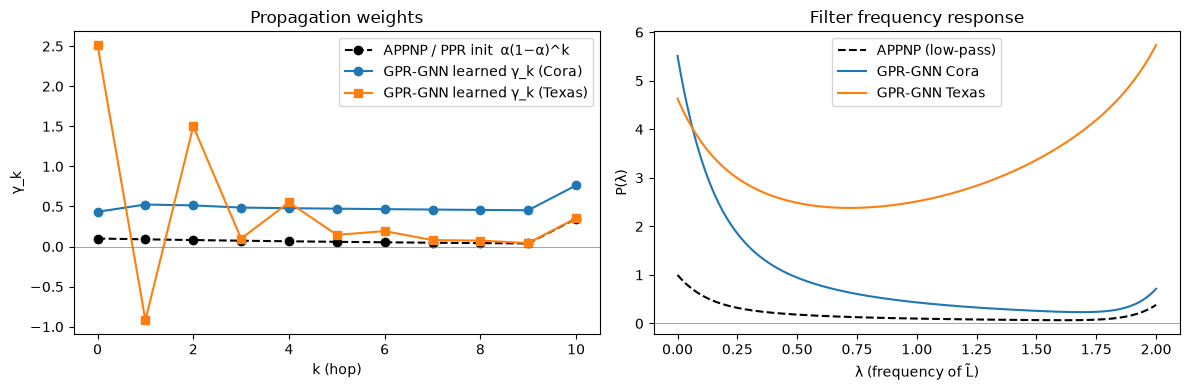

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
K = len(gpr_cora.gamma) - 1
ppr = [0.1 * 0.9 ** k for k in range(K)] + [0.9 ** K]
ax[0].plot(ppr, 'k--o', label='APPNP / PPR init  α(1−α)^k')
ax[0].plot(gpr_cora.gamma.detach().cpu(), 'o-', label='GPR-GNN learned γ_k (Cora)')
ax[0].plot(gpr_texas.gamma.detach().cpu(), 's-', label='GPR-GNN learned γ_k (Texas)')
ax[0].axhline(0, color='grey', lw=0.5); ax[0].set_xlabel('k (hop)'); ax[0].set_ylabel('γ_k'); ax[0].legend()
ax[0].set_title('Propagation weights')

# spectral response  P(λ) = Σ_k γ_k (1 − λ)^k  of the filter on L̃
lam = torch.linspace(0, 2, 200)
def response(g):
    return sum(float(g[k]) * (1 - lam) ** k for k in range(len(g)))
ax[1].plot(lam, response(ppr), 'k--', label='APPNP (low-pass)')
ax[1].plot(lam, response(gpr_cora.gamma.detach().cpu()), label='GPR-GNN Cora')
ax[1].plot(lam, response(gpr_texas.gamma.detach().cpu()), label='GPR-GNN Texas')
ax[1].axhline(0, color='grey', lw=0.5); ax[1].set_xlabel('λ (frequency of L̃)'); ax[1].set_ylabel('P(λ)')
ax[1].set_title('Filter frequency response'); ax[1].legend()
plt.tight_layout(); plt.show()

## 6.5. JKNet
Every intermediate representation jumps to the last layer, and the aggregator (concatenation, max-pooling, or LSTM-attention) picks the effective neighbourhood size for each node.

In [48]:
class JKNet(nn.Module):
    """Jumping Knowledge Network (Xu et al., ICML 2018): every layer 'jumps' to the output.
       mode 'cat'  : [h¹ || ... || h^k]
       mode 'max'  : element-wise max over layers
       mode 'lstm' : bi-LSTM over the layer sequence -> attention score per layer -> weighted sum"""
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers=6, mode='cat', dropout=0.5):
        super().__init__()
        self.layers = nn.ModuleList([GCNLayer(in_dim if i == 0 else hidden_dim, hidden_dim)
                                     for i in range(num_layers)])
        self.mode, self.dropout = mode, dropout
        if mode == 'lstm':
            self.lstm = nn.LSTM(hidden_dim, hidden_dim // 2, bidirectional=True, batch_first=True)
            self.att = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(num_layers * hidden_dim if mode == 'cat' else hidden_dim, out_dim)

    def forward(self, x, adj):
        hs = []
        for layer in self.layers:
            x = F.relu(layer(F.dropout(x, self.dropout, self.training), adj))
            hs.append(x)
        if self.mode == 'cat':
            h = torch.cat(hs, dim=1)
        elif self.mode == 'max':
            h = torch.stack(hs, dim=0).max(dim=0)[0]
        else:
            seq = torch.stack(hs, dim=1)                            # N × L × d
            score = self.att(self.lstm(seq)[0]).squeeze(-1)         # N × L
            self.layer_weights = score.softmax(dim=1)               # per-node attention over layers
            h = (seq * self.layer_weights.unsqueeze(-1)).sum(dim=1)
        return self.fc(F.dropout(h, self.dropout, self.training))

In [ ]:
for mode in ['cat', 'max', 'lstm']:
    set_seed(0)
    jk = JKNet(num_features, 64, num_classes, num_layers=6, mode=mode)
    _, acc = train_model(jk, (X, A_hat), epochs=300, verbose=False)
    print(f'JKNet 6 layers | mode = {mode:<4} | Test Acc: {acc*100:.2f}%')
    if mode == 'cat':
        results['JKNet'] = acc
# which layers does the LSTM-attention use? (average attention weight per layer)
jk.eval()
with torch.no_grad():
    jk(X, A_hat)
print('Mean LSTM-attention weight per layer:', np.round(jk.layer_weights.mean(dim=0).cpu().numpy(), 3))

JKNet 6 layers | mode = cat  | Test Acc: 79.30%
JKNet 6 layers | mode = max  | Test Acc: 79.80%
JKNet 6 layers | mode = lstm | Test Acc: 76.30%
Mean LSTM-attention weight per layer: [0.028 0.477 0.165 0.237 0.073 0.02 ]


# 7. Summary
| Remedy family | Models | Main target |
|---|---|---|
| Skip connections | DeepGCNs, GCNII | Optimisation, over-smoothing |
| Normalisation, regularisation | PairNorm, DropEdge | Over-smoothing, overfitting |
| Graph rewiring | SDRF, FoSR, DIGL | Over-squashing |
| Global attention | GraphGPS | Over-squashing, under-reaching |
| Multi-hop aggregation | MixHop, SIGN, APPNP, GPR-GNN, JKNet | Under-reaching, over-smoothing |

Configurations in the chart below:
- **DeepGCN:** 16 layers, res+.
- **GCNII:** 64 layers.
- **PairNorm:** 32 layers + residual, mean of 3 seeds.
- **DropEdge:** 4 layers, p = 0.5, mean of 3 seeds.
- **Rewiring rows:** 2-layer GCN on the rewired largest connected component.
- **GraphGPS:** 4 layers with RWPE.
- **APPNP / GPR-GNN:** K = 10.
- **JKNet:** 6 layers, concat.

Note: Cora is homophilous and needs only short-range information, so a 2-layer GCN is already a strong baseline. The point of these remedies is that they let a model go **deeper and reach further without collapsing** (compare with the 32-layer plain GCN at about 20%).